# Preprocessing Quality Control (UTSW, 619 processed patients)

**Purpose.** Before training anything, confirm that the cropped arrays written by `src/process_chunk.py` are what we think they are, and decide whether a minimum tumor-volume rule is needed.


About data and this notebook:
1. The current crop size is a 128 x 128 x 128 window around the tumor, which is what the CNN will see.
2. Quality checks are on images and segmentations only. 
3. Outputs are aggregates (counts, distributions, plots). No patient IDs or paths are printed.

Quality Checks: 
1. crop coverage (from the log)
2. array integrity 
3. intensity distributions
4. tumor volume and the minimum-volume question 
5. visual review

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.config import PROCESSED, LOG, MANIFEST, DATA
from src.preprocessing import CONTRASTS, CROP

log = pd.read_csv(LOG).drop_duplicates("patient_id", keep="last")   # latest attempt per patient
m = pd.read_csv(MANIFEST)
cohort = m.merge(log[log.status == "ok"], on="patient_id")

print(len(m), "in manifest;", log.status.value_counts().to_dict())
print(len(cohort), "usable;", cohort.idh.value_counts().to_dict())
print("npz files on disk:", len(list(PROCESSED.glob("*.npz"))))
print("manifest columns:", list(m.columns))

622 in manifest; {'ok': 619, 'failed': 3}
619 usable; {0: 443, 1: 176}
npz files on disk: 619
manifest columns: ['patient_id', 'idh', 'age', 'sex', 'idh_method', 'scanner_group', 'scanner_make', 'has_manual_seg', 'fold', 'processed']


## Crop coverage

These numbers come from the processing log, not from re-reading the arrays. These are the statistics assessed: 

- `exceeds_crop`: a true/false column that states whether the tumor exceeds the crop 
- `tumor_in_crop`: measures how many of the tumor voxels fits inside the crop (as a ratio), whereas `exceeds_crop` is solely true or false
- `main_fraction`: ratio of voxel count of the largest chunk of tumor and the total tumor voxel count (ex. main_fraction = 1 means the tumor is a single piece, whereas main_function = 0.8 means the largest tumor chunk makes up 80% of the total tumor segmented). Essentially, measures fragmentation of the tumor. 
- `tumor_in_brain`: measures how many tumor voxels fits in the brain mask (as a ratio), checked on T1 contrast. 

Ideally, the `tumor_in_crop` and `tumor_in_brain` should both be 1.0. This check is a limitation of the crop size and centering method, as well as a limiation of automated segmentation (FeTS). 

Number of patients with the tumor box longer than the crop on some axis: 3
Number of patients with <99% of tumor voxels inside the crop: 5 (worst 0.956)
Number of patients where the largest tumor piece makes up <90% of total tumor: 44
How much of the tumor is inside the T1 brain mask: median 1.000, min 0.9889


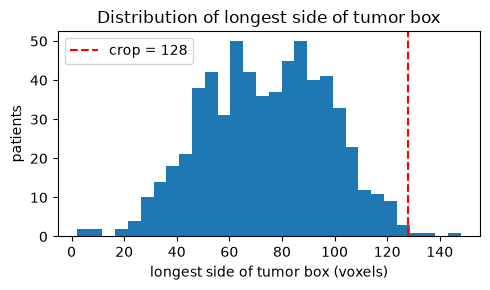

In [68]:
ok = log[log.status == "ok"].copy()
ok["longest_side"] = ok[["bbox_x", "bbox_y", "bbox_z"]].max(axis=1)
ok["lt99"] = ok.tumor_in_crop < 0.99

print("Number of patients with the tumor box longer than the crop on some axis:", int(ok.exceeds_crop.sum()))
print(f"Number of patients with <99% of tumor voxels inside the crop: {int((ok.lt99).sum())} (worst {ok.tumor_in_crop.min():.3f})")
print(f"Number of patients where the largest tumor piece makes up <90% of total tumor: {int((ok.main_fraction < 0.9).sum())}")
print(f"How much of the tumor is inside the T1 brain mask: median {ok.tumor_in_brain.median():.3f}, min {ok.tumor_in_brain.min():.4f}")

# Distribution of the longest side of the tumor box
plt.figure(figsize=(5, 3))
plt.hist(ok.longest_side, bins=30)
plt.axvline(CROP, color="r", ls="--", label=f"crop = {CROP}")
plt.title("Distribution of longest side of tumor box")
plt.xlabel("longest side of tumor box (voxels)"); plt.ylabel("patients"); plt.legend()
plt.tight_layout(); plt.show()

In [ ]:
# Crosstab of patients with tumor box exceeding crop size vs. patients with <99% of tumor voxels inside the crop
print(pd.crosstab(ok.exceeds_crop, ok.lt99))   # rows: box too long; columns: <99% kept

cols = ["longest_side", "n_components", "main_fraction", "tumor_in_crop"]
print(ok.loc[ok.exceeds_crop | ok.lt99, cols].round(3).to_string(index=False))

lt99          False  True 
exceeds_crop              
False           612      4
True              2      1
 longest_side  n_components  main_fraction  tumor_in_crop
        148.0           2.0          1.000          0.979
         95.0           4.0          0.970          0.970
        132.0           7.0          0.999          0.999
        138.0           1.0          1.000          0.998
         91.0          15.0          0.818          0.956
         93.0          15.0          0.711          0.965
        100.0          14.0          0.784          0.989


**Findings**: 
The 128 crop size window contains the segmented tumor almost completely. 612 patients (98.9%) have a tumor box that fits inside the window and keep at least 99% of their tumor voxels. 
- 3 patients have a tumor box longer than 128 voxels on at least one axis (longest sides: 132, 138 and 148). Two of these still keep at least 99.8% of their tumor voxels, whereas the 148-voxel tumor keeps 97.9%.
- 5 patients keep less than 99% of their tumor voxels (worst 95.6%). Four of which have tumor boxes that fit in the window but have several separate tumor pieces (4 to 15), and the window leaves out small distant fragments.
- 44 patients have a fragmented segmentation (largest piece under 90% of the tumor); only 3 of them lose more than 1% of tumor voxels in the crop.
- Skull-stripping clipped almost no tumor (tumor inside the brain mask: median 1.000, minimum 0.989).

**Limitation:** these figures measure coverage of the FeTS automated segmentation, not of the true tumor, and a few very large or widely separated tumors can be partly cut off at the window edge. With so few affected patients, this should not change the cohort-level results, but will be reported as a limitation.

## Array Integrity Check

Open every saved `.npz` once and check the things that would silently break training: wrong shape, NaN/inf, an empty contrast channel, an empty mask, or tumor lying in zero-valued background (which would mean the mask and image are misaligned). It also records whether the tumor touches the crop border.

Another thing assessed here is brain fraction, which is the proportion of nonzero voxels in the cropped array. The zeros are from the background or zero padding where the window extends beyond a scan. A brain fraction of 0.5 means that 50% of the cropped image consist of nonzero brain voxels, while the other 50% is zero voxels. 

This reads about 4 GB from disk, one patient at a time, so it takes a few minutes. The result is cached in `Data/qc_arrays.csv`; delete that file to re-run.

In [ ]:
QC_CSV = DATA / "qc_arrays.csv"
# Create a boolean mask for the border of the crop, which will be used to check if the tumor touches the border
# this results in a 3D array of shape (CROP, CROP, CROP) where the border voxels are True and the inner voxels are False
border = np.ones((CROP,) * 3, bool); border[1:-1, 1:-1, 1:-1] = False

def check_patient(pid):
    z = np.load(PROCESSED / f"{pid}.npz")
    img = z["image"].astype(np.float32)
    mask = z["mask"] > 0
    row = dict(patient_id=pid,
               shape_ok=img.shape == (len(CONTRASTS), CROP, CROP, CROP) and mask.shape == (CROP,) * 3,
               finite=bool(np.isfinite(img).all()),
               mask_voxels=int(mask.sum()),
               touches_border=bool((mask & border).any()))
    for i, name in enumerate(CONTRASTS):
        brain = img[i] != 0                     # background is exactly 0 after preprocessing
        v = img[i][brain]
        row[f"{name}_brain_frac"] = brain.mean()
        row[f"{name}_mean"] = v.mean() if v.size else np.nan
        row[f"{name}_std"] = v.std() if v.size else np.nan
        row[f"{name}_tumor_in_brain"] = brain[mask].mean() if mask.any() else np.nan
    return row

if QC_CSV.exists():
    qc = pd.read_csv(QC_CSV)
else:
    qc = pd.DataFrame([check_patient(p) for p in cohort.patient_id])
    qc.to_csv(QC_CSV, index=False)
assert set(qc.patient_id) == set(cohort.patient_id), "cache is stale: delete Data/qc_arrays.csv"
print(len(qc), "arrays checked")

619 arrays checked


In [5]:
print("wrong shape:", int((~qc.shape_ok).sum()), "| non-finite values:", int((~qc.finite).sum()),
      "| empty mask:", int((qc.mask_voxels == 0).sum()))
print("tumor touches crop border:", int(qc.touches_border.sum()))

for c in CONTRASTS:
    print(f"{c}: brain fraction of crop min {qc[c+'_brain_frac'].min():.2f}, "
          f"tumor-in-brain min {qc[c+'_tumor_in_brain'].min():.3f}, "
          f"patients with tumor-in-brain < 0.99: {int((qc[c+'_tumor_in_brain'] < 0.99).sum())}")

wrong shape: 0 | non-finite values: 0 | empty mask: 0
tumor touches crop border: 24
brain_t1: brain fraction of crop min 0.11, tumor-in-brain min 0.989, patients with tumor-in-brain < 0.99: 1
brain_t1ce: brain fraction of crop min 0.11, tumor-in-brain min 0.989, patients with tumor-in-brain < 0.99: 1
brain_t2: brain fraction of crop min 0.11, tumor-in-brain min 0.989, patients with tumor-in-brain < 0.99: 1
brain_flair: brain fraction of crop min 0.11, tumor-in-brain min 0.989, patients with tumor-in-brain < 0.99: 1


In [ ]:
# Crosstab of patients with tumor touching the crop border vs. patients with <99% of tumor voxels inside the crop
# Goal: check how much of the tumor is being lost due to cropping
d = qc.merge(log[["patient_id", "tumor_in_crop"]], on="patient_id")
d["lt99"] = d.tumor_in_crop < 0.99
print(pd.crosstab(d.touches_border, d.lt99))        # border contact vs measured loss
print(qc.brain_t1_brain_frac.describe(percentiles=[.01, .05, .5]).round(2))

lt99            False  True 
touches_border              
False             593      2
True               21      3
count    619.00
mean       0.45
std        0.08
min        0.11
1%         0.26
5%         0.32
50%        0.45
max        0.66
Name: brain_t1_brain_frac, dtype: float64


In [ ]:
# Show the 5 patients with the lowest fraction of T1 brain voxels in the crop
low = qc.nsmallest(5, "brain_t1_brain_frac")
print(low[["brain_t1_brain_frac", "mask_voxels", "touches_border"]].round(2).to_string(index=False))

 brain_t1_brain_frac  mask_voxels  touches_border
                0.11           38           False
                0.20        10991           False
                0.22        38327            True
                0.23         7901           False
                0.23        27731           False


**Findings:**
All 619 processed arrays have the expected shape (4 × 128x128x128 image, 128x128x128 mask), contain no NaN or infinite values, and have a non-empty mask. The minimum fraction of tumor voxels inside the brain mask is 0.989 for all four contrasts, with one patient below 0.99. 

24 patients have tumor voxels on the crop border. Of these, 21 keep at least 99% of their tumor voxels and 3 keep less. Two further patients keep less than 99% without touching the border, likely due to a small separate fragment that lies entirely outside the window. 

Brain fraction of the crop has a median of 0.45 (1st percentile 0.26). The crop with the lowest brain fraction (0.11) belongs to a patient with a 38-voxel tumor. The next four (0.20 to 0.23) have tumors of 7,901 to 38,327 voxels and were reviewed visually in section 5.

## Intensity Distributions

After z-scoring the whole scan, the crop mean and standard deviation will not be exactly 0 and 1 (the crop contains the tumor, which is brighter or darker than average brain). Checking the intensity distribution across scanner brands is also important as large deviations in intensity indicates a lack of uniformity across scans. This check just ensures that no patient or scanner group is wildly off. Scanner make is used here only for this check, never as a model feature.

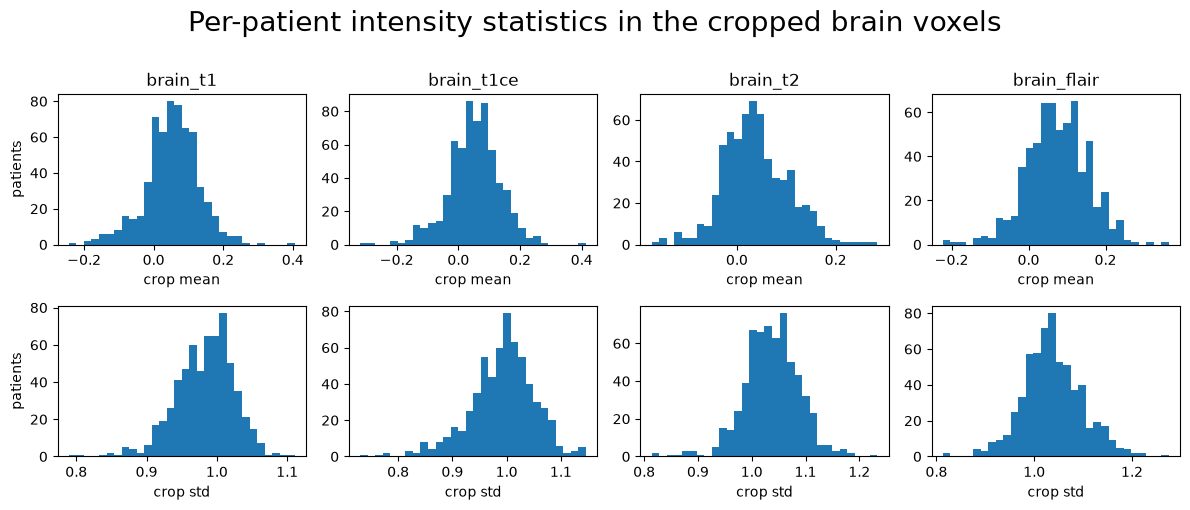

In [ ]:
fig, axes = plt.subplots(2, len(CONTRASTS), figsize=(12, 5))
for j, c in enumerate(CONTRASTS):
    axes[0, j].hist(qc[c + "_mean"], bins=30)
    axes[0, j].set_title(c) 
    axes[0, j].set_xlabel("crop mean")
    axes[1, j].hist(qc[c + "_std"], bins=30)
    axes[1, j].set_xlabel("crop std")
axes[0, 0].set_ylabel("patients"); axes[1, 0].set_ylabel("patients")
fig.suptitle("Per-patient intensity statistics in the cropped brain voxels", y=1.01, size=20)
plt.tight_layout(); plt.show()

In [33]:
SCANNER_COL = "scanner_make"   # adjust to the real column name printed in section 0
d = qc.merge(cohort[["patient_id", SCANNER_COL]], on="patient_id")
cols = [c + s for c in CONTRASTS for s in ("_mean", "_std")]
print(d.groupby(SCANNER_COL)[cols].median().round(2).T)
print(d[SCANNER_COL].value_counts().to_dict())

scanner_make        GE  Hitachi  Not Reported  Philips  Siemens  Toshiba
brain_t1_mean     0.08     0.03          0.03     0.06     0.05    -0.16
brain_t1_std      0.97     0.97          0.99     0.99     0.99     0.94
brain_t1ce_mean   0.07    -0.00          0.05     0.05     0.05    -0.21
brain_t1ce_std    0.99     0.99          1.01     1.00     1.00     0.84
brain_t2_mean     0.01     0.01          0.02     0.06     0.03    -0.00
brain_t2_std      1.02     1.03          1.03     1.05     1.04     1.06
brain_flair_mean  0.06     0.05          0.07     0.10     0.07    -0.09
brain_flair_std   1.03     1.03          1.04     1.06     1.03     0.99
{'Siemens': 265, 'GE': 170, 'Philips': 140, 'Not Reported': 28, 'Hitachi': 15, 'Toshiba': 1}


**Findings:** The per-patient mean and std histograms show no multimodal distributions or extreme values after z-scoring. Median statistics are similar across the three large vendor groups (Siemens, GE, Philips; 575 of 619 patients). Hitachi (n=15), Toshiba (n=1) and Not Reported (n=28) are too small to compare. Since z-scoring equalizes global intensity statistics by construction, this check confirms the normalization ran, not that scanner effects were removed; scanner is therefore analyzed through subgroup results.

## Tumor volume and the minimum-volume question

`mask_voxels` is the tumor volume in $mm^3$ (1 mm voxels). It is measured inside the crop, so for the few cut-off tumors it is a slight underestimate.

Why a very small segmentation matters: the crop is centered on the significant tumor sections, so a tumor of a few voxels gives a $128^3$ window that is almost all normal brain. The CNN would then be classifying from essentially an MRI scan of a normal brain which could add noise to a dataset meant for gliomas. Other things to consider: the FeTS (the automated segmentation tool) could have missed the real tumor or that the finding is a real tiny lesion. 

The 3 patients already excluded had a failed segmentation of exactly 0 voxels. A small segmentation close to 0 is the same failure in practice, which is why a volume threshold is a more consistent rule than excluding just the failed segmentation.

In [53]:
vol = qc.mask_voxels
print(vol.describe(percentiles=[.01, .05, .25, .5, .75, .95]).round(0))
print("15 smallest volumes (voxels):", np.sort(vol.values)[:15].tolist())

count       619.0
mean      84711.0
std       63800.0
min           2.0
1%         1444.0
5%         8203.0
25%       34434.0
50%       69500.0
75%      126625.0
95%      204102.0
max      325707.0
Name: mask_voxels, dtype: float64
15 smallest volumes (voxels): [2, 38, 94, 137, 870, 1037, 1360, 1827, 2971, 3046, 3072, 4193, 4388, 4468, 4832]


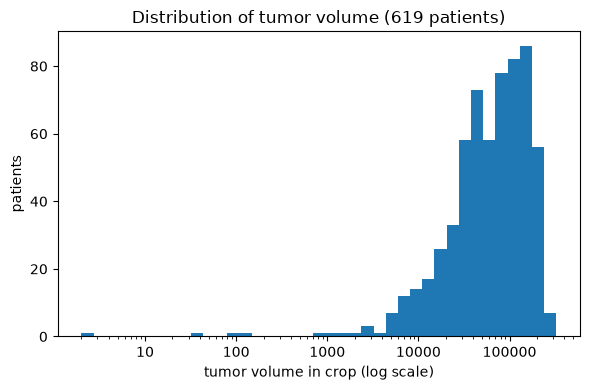

In [64]:
from matplotlib.ticker import ScalarFormatter

bins = np.logspace(np.log10(vol.min()), np.log10(vol.max()), 40)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(vol, bins=bins)
ax.set_xscale("log")
ax.xaxis.set_major_formatter(ScalarFormatter())     # plain numbers (0.1, 1, 10, 100) instead of 10^n
ax.set_xlabel("tumor volume in crop (log scale)")
ax.set_ylabel("patients")
ax.set_title(f"Distribution of tumor volume ({len(vol)} patients)")
plt.tight_layout(); plt.show()

In [13]:
# Candidate thresholds: counts only, no labels, so the choice is not influenced by IDH.
cands = [10, 50, 100, 500, 1000, 2000]
print(pd.DataFrame({"min_voxels": cands,
                    "excluded": [int((vol < t).sum()) for t in cands],
                    "remaining": [int((vol >= t).sum()) for t in cands]}).to_string(index=False))

 min_voxels  excluded  remaining
         10         1        618
         50         2        617
        100         3        616
        500         4        615
       1000         5        614
       2000         8        611


**Findings:** Tumor volume ($mm^3$ at 1 mm voxels) has a median of 69,500 voxels (interquartile range (IQR) of 34,434 to 126,625). Four patients have segmentations of 137 voxels or fewer. While the 5th smallest has 870 voxels (about 6-fold bigger). A minimum of 500 voxels would exclude exactly these four patients. The visual review below will confirm and finalize the minimum voxel threshold. 

## Visual review

The images have: the axial slice with the most tumor, all four contrasts, FeTS whole-tumor outline in red. Rows are labeled by rank, not patient ID. Things to look for: does the outline sit on something that looks like a lesion in FLAIR / post-contrast T1? Are the four contrasts aligned with each other? (The slice is taken along the last array axis; the image is transposed for display only.)

First the 8 smallest tumors (to judge the threshold), then 4 random patients (to confirm the pipeline looks sane in general), and the 5 scans with the lowest brain fraction (to see why there is so little brain voxels in the crop)

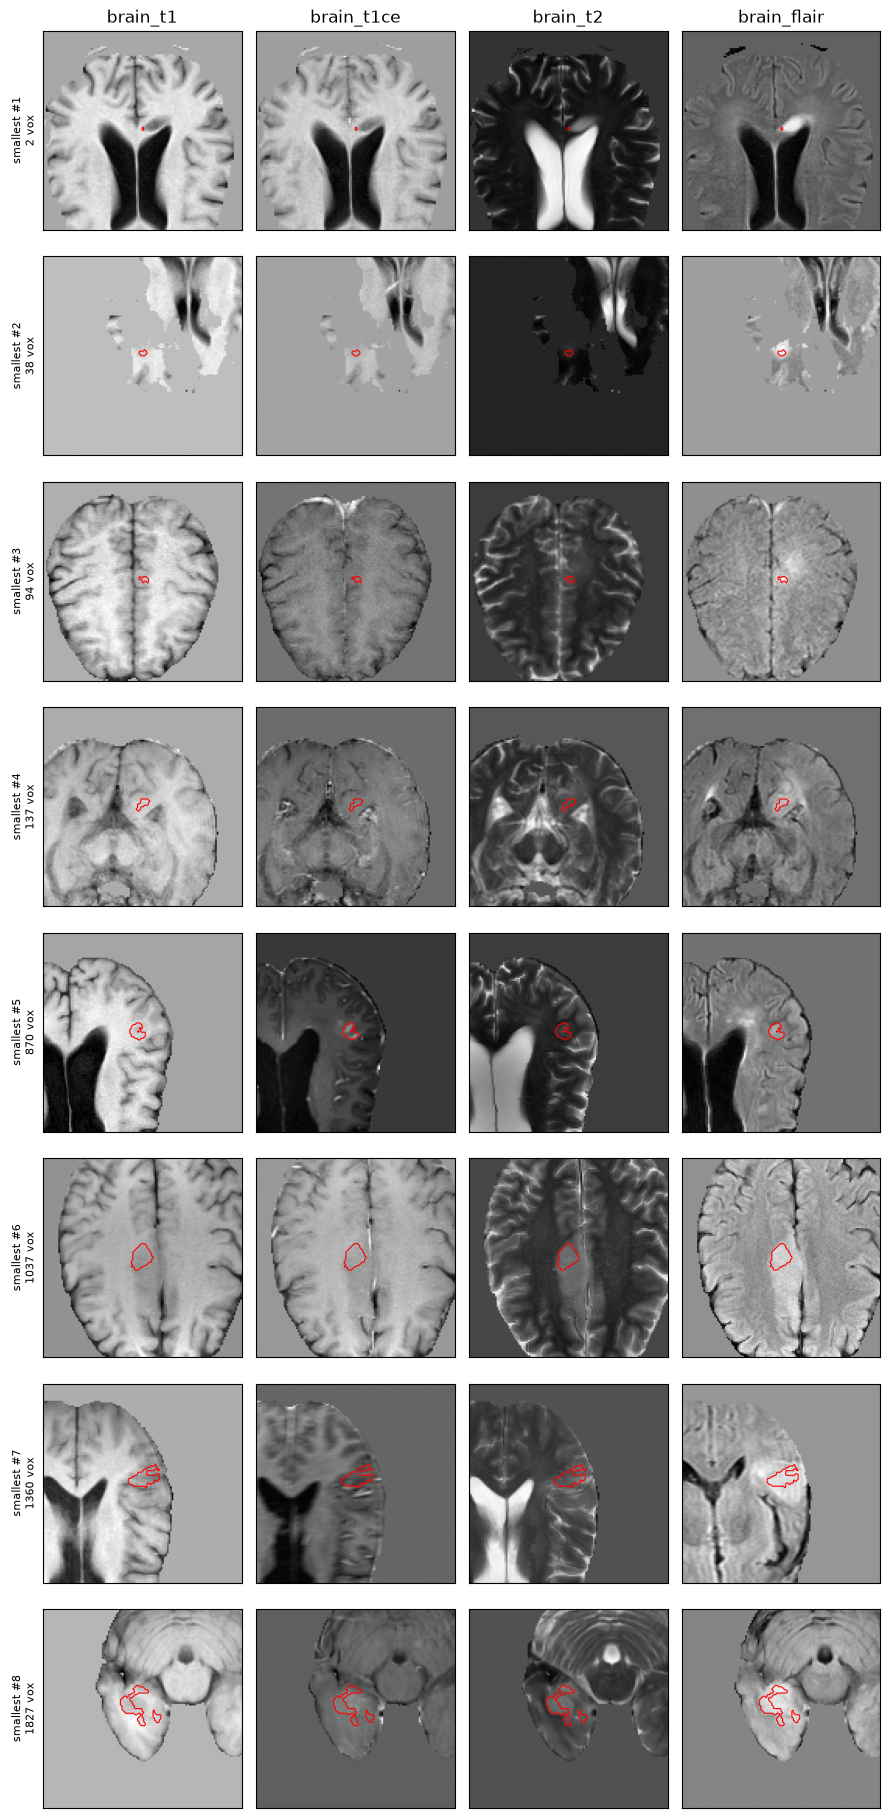

In [46]:
def show(pids, labels):
    fig, axes = plt.subplots(len(pids), len(CONTRASTS), figsize=(9, 2.3 * len(pids)), squeeze=False)
    for r, (pid, lab) in enumerate(zip(pids, labels)):
        z = np.load(PROCESSED / f"{pid}.npz")
        img = z["image"].astype(np.float32); mask = z["mask"] > 0
        s = int(mask.sum((0, 1)).argmax())
        for c, name in enumerate(CONTRASTS):
            ax = axes[r, c]
            ax.imshow(img[c, :, :, s].T, cmap="gray", origin="lower")
            if mask[:, :, s].any():
                ax.contour(mask[:, :, s].T, levels=[0.5], colors="r", linewidths=0.8)
            ax.set_xticks([]); ax.set_yticks([])
            if r == 0: ax.set_title(name)
            if c == 0: ax.set_ylabel(f"{lab}\n{int(mask.sum())} vox", fontsize=8)
    plt.tight_layout(); plt.show()

order = qc.sort_values("mask_voxels").patient_id.tolist()
show(order[:8], [f"smallest #{i+1}" for i in range(8)])

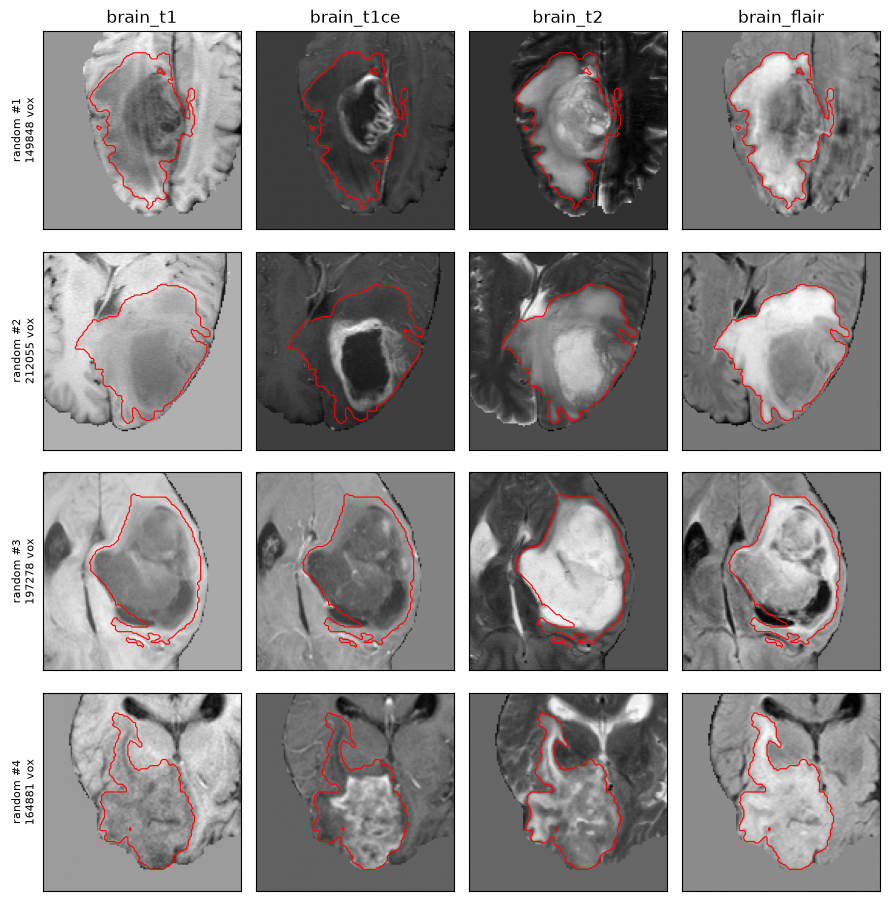

In [15]:
rng = np.random.default_rng(42)
pick = rng.choice(qc.patient_id.values, 4, replace=False).tolist()
show(pick, [f"random #{i+1}" for i in range(4)])

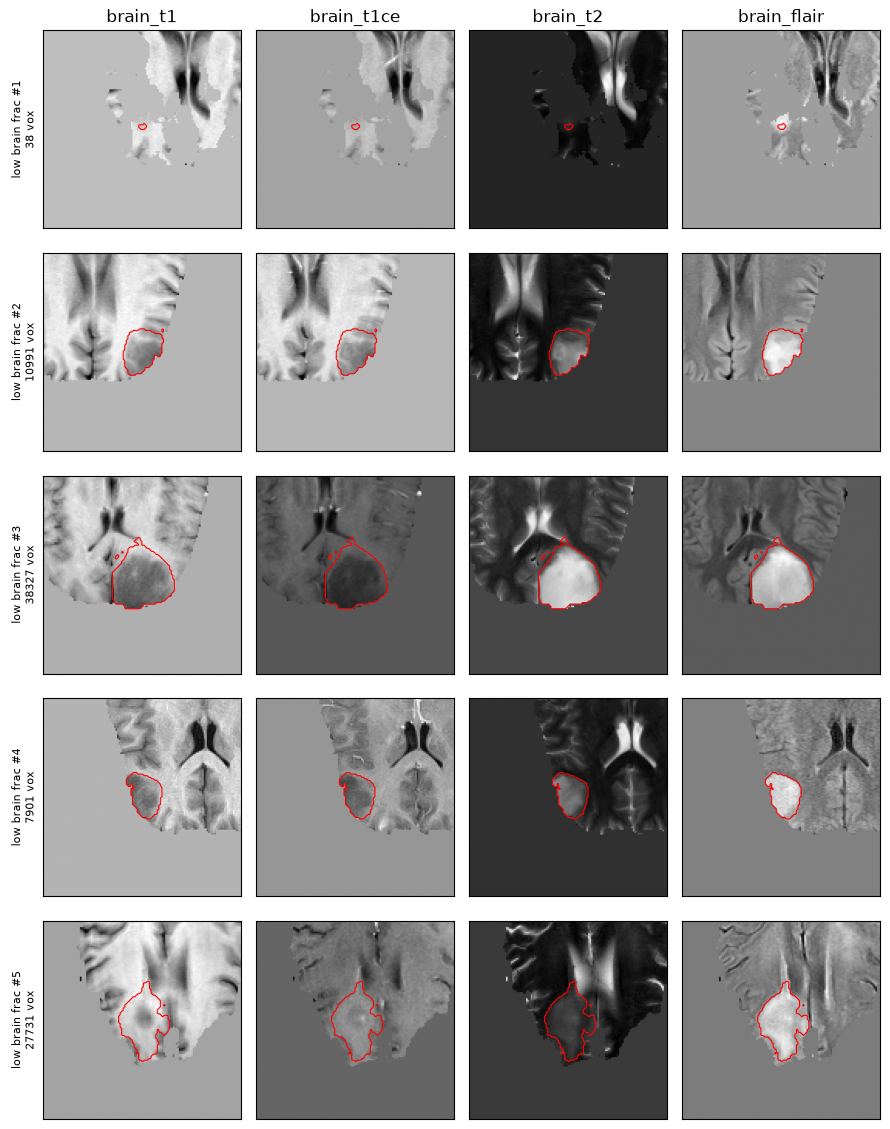

In [47]:
low = qc.nsmallest(5, "brain_t1_brain_frac")
show(low.patient_id.tolist()[:5], [f"low brain frac #{i+1}" for i in range(5)])

**Findings:** The smallest segmentation (2 voxels) appears to be a near empty segmentation, but next to the outline appears to be an unsegmented abnormality. The 2nd smallest (38 voxels) appears to be a failure as there is a fragmentary brain mask. The next two (94 and 137 voxels) outline small abnormalities, but it appears that the segmentation potentially failed as some abnormalities of possible tumors were not outlined. 
Thus, there is a case to be made of either setting the threshold to 50 voxels, which removes the 2 smallest segmentations (2 and 38 voxels) or setting the threshold to 500 voxels to remove the 4 smallest. This demonstrates the limitation of the automated segmentation (FeTS).

The next four (870 to 1,827 voxels) outline visible lesions. The four contrasts are aligned in all reviewed patients. The random patients appeared as expected and clear. The crops with the lowest brain fraction belong to posterior tumors near the edge of the brain, apart from the 38-voxel patient. These were retained.

## Decision and summary

Determine `MIN_TUMOR_VOXELS` based on the visual review, using the volume distribution and what the outlines show. Whatever is chosen is applied unchanged to UCSF-PDGM (same rule, decided before looking at UCSF), and the number excluded is reported in both cohorts.

The last cell reports the IDH composition of the excluded patients purely as a transparency check and if it removes one class disproportionately.

In [ ]:
MIN_TUMOR_VOXELS = 50     # set from volume distribution and visual inspection of the smallest tumors

if MIN_TUMOR_VOXELS is None:
    print("No minimum-volume rule set yet.")
else:
    d = cohort[["patient_id", "idh"]].merge(qc[["patient_id", "mask_voxels"]])
    flagged = d[d.mask_voxels < MIN_TUMOR_VOXELS]
    print(f"rule: tumor < {MIN_TUMOR_VOXELS} voxels -> excludes {len(flagged)} of {len(d)}")
    print("IDH of excluded:", flagged.idh.value_counts().to_dict(),
          "| IDH of remaining:", d[d.mask_voxels >= MIN_TUMOR_VOXELS].idh.value_counts().to_dict())

rule: tumor < 50 voxels -> excludes 2 of 619
IDH of excluded: {1: 1, 0: 1} | IDH of remaining: {0: 442, 1: 175}


**Finalized Exclusion Rule:** exclude segmentations under 50 voxels (set from the volume distribution and visual review). This excludes 2 of 619 patients (0.3%): one mutant, one wildtype. From a total of 625 patients, 3 had no IDH label, 3 had empty segmentation, and 2 were excluded here due to small tumor size. This leaves 617 patients (175 mutant, 442 wildtype). A stricter threshold of 500 voxels would have excluded 4 patients and was not adopted, because the 94- and 137-voxel patients show a visible abnormality at the segmented location in FLAIR, which could have been due to a failure in the automated segmentation tool. 